In [504]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import math

import sys
sys.path.append("../../")
from common import *

градуировка монохроматора по неону

In [505]:
baraban_Ne = [2200, 2208, 2244, 2512, 2528, 2558, 2574, 2598, 2616, 2628, 2648, 2660, 2678, 2695, 2712, 2724, 2744, 2751, 2788, 2799, 2822, 2846, 2860, 2932, 2961]
lambda_Ne  = [5331, 5341, 5401, 5852, 5882, 5945, 5976, 6030, 6074, 6096, 6143, 6164, 6217, 6267, 6305, 6334, 6383, 6402, 6507, 6533, 6599, 6678, 6717, 6929, 7032]

градуировка спектрометра по ртути

In [506]:
baraban_Hg = [ 2926,  2689, 2480,   2466,  2288,  1866,  1206,  662]
lambda_Hg  = [690.7, 623.4, 579.1, 577.0, 546.1, 491.6, 435.8, 404.7]

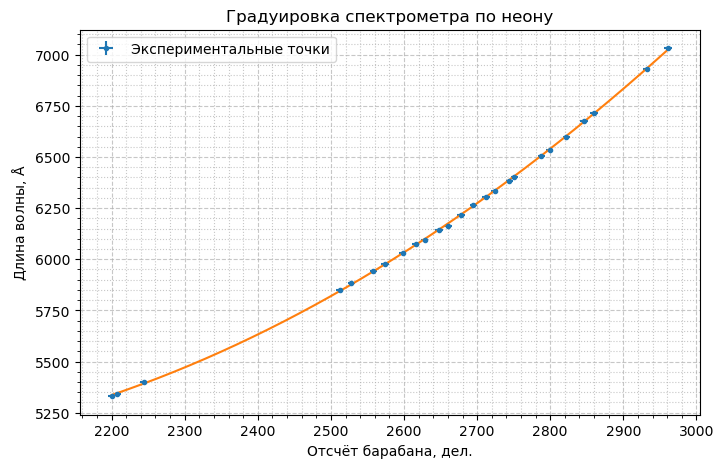

Лучшая степень полинома: 2
Коэффициенты (от старшей степени к свободному члену):
1.316686e-03
-4.576579e+00
9.032160e+03

Итоговый полином калибровки λ(x):
          2
0.001317 x - 4.577 x + 9032


In [507]:
x = np.array(baraban_Ne, dtype=float)
y = np.array(lambda_Ne, dtype=float)

xerr = np.full_like(x, 5.0)      # погрешность отсчёта барабана
yerr = np.full_like(y, 5.0)      # эффективная погрешность λ (Å)

degrees = [1, 2]
best = None

for deg in degrees:
    coeffs = np.polyfit(x, y, deg)
    p = np.poly1d(coeffs)
    residuals = y - p(x)
    chi2 = np.sum((residuals / yerr) ** 2)
    k = deg + 1
    n = len(x)
    bic = n * np.log(chi2 / n) + k * np.log(n)
    if best is None or bic < best["bic"]:
        best = {"deg": deg, "coeffs": coeffs, "poly": p, "chi2": chi2, "bic": bic}

calib_poly_Ne = best["poly"]

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='.', label=r'Экспериментальные точки')
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = calib_poly_Ne(x_fit)
plt.plot(x_fit, y_fit)

plt.xlabel(r'Отсчёт барабана, дел.')
plt.ylabel(r'Длина волны, $\mathrm{\AA}$')
plt.title(r'Градуировка спектрометра по неону')

plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':',  alpha=0.7, which='minor')
plt.legend()
plt.show()

print(f"Лучшая степень полинома: {best['deg']}")
print("Коэффициенты (от старшей степени к свободному члену):")
for c in best["coeffs"]:
    print(f"{c:.6e}")
print("\nИтоговый полином калибровки λ(x):")
print(calib_poly_Ne)

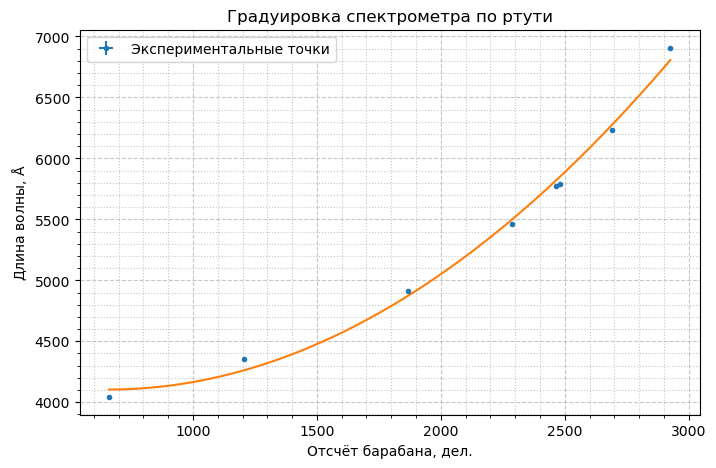

Лучшая степень полинома: 2
Коэффициенты (от старшей степени к свободному члену):
5.251089e-04
-6.907410e-01
4.331481e+03

Итоговый полином калибровки λ(x):
           2
0.0005251 x - 0.6907 x + 4331


In [508]:
x = np.array(baraban_Hg, dtype=float)
y = np.array(lambda_Hg, dtype=float) * 10

xerr = np.full_like(x, 5.0)      # погрешность отсчёта барабана
yerr = np.full_like(y, 5.0)      # эффективная погрешность λ (Å)

degrees = [1, 2]
best = None

for deg in degrees:
    coeffs = np.polyfit(x, y, deg)
    p = np.poly1d(coeffs)
    residuals = y - p(x)
    chi2 = np.sum((residuals / yerr) ** 2)
    k = deg + 1
    n = len(x)
    bic = n * np.log(chi2 / n) + k * np.log(n)
    if best is None or bic < best["bic"]:
        best = {"deg": deg, "coeffs": coeffs, "poly": p, "chi2": chi2, "bic": bic}

calib_poly_Hg = best["poly"]

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='.', label=r'Экспериментальные точки')
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = calib_poly_Hg(x_fit)
plt.plot(x_fit, y_fit)

plt.xlabel(r'Отсчёт барабана, дел.')
plt.ylabel(r'Длина волны, $\mathrm{\AA}$')
plt.title(r'Градуировка спектрометра по ртути')

plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':',  alpha=0.7, which='minor')
plt.legend()
plt.show()

print(f"Лучшая степень полинома: {best['deg']}")
print("Коэффициенты (от старшей степени к свободному члену):")
for c in best["coeffs"]:
    print(f"{c:.6e}")
print("\nИтоговый полином калибровки λ(x):")
print(calib_poly_Hg)

In [509]:
calib_poly_Hg(2350)

np.float64(5608.153932197295)

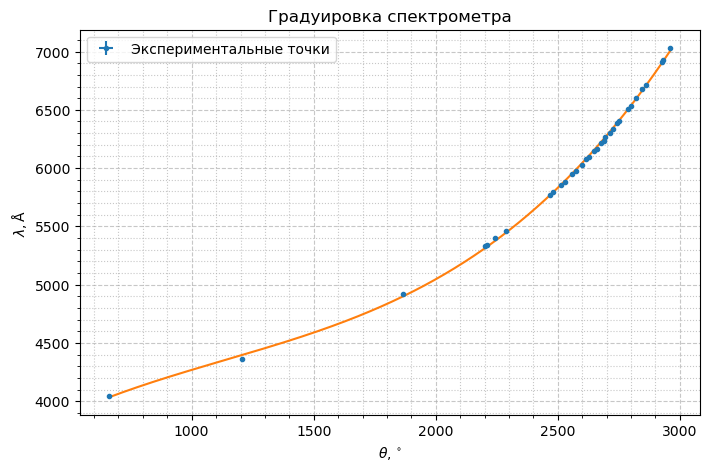

Лучшая степень полинома: 3
Коэффициенты (от старшей степени к свободному члену):
2.528443e-07
-8.627887e-04
1.596488e+00
3.281930e+03

Итоговый полином калибровки λ(x):
           3             2
2.528e-07 x - 0.0008628 x + 1.596 x + 3282


In [510]:
baraban_combined = baraban_Hg + baraban_Ne
lambda_combined = [l * 10 for l in lambda_Hg] + lambda_Ne
x = np.array(baraban_combined, dtype=float)
y = np.array(lambda_combined, dtype=float)

xerr = np.full_like(x, 5.0)
yerr = np.full_like(y, 5.0)

degrees = [1, 2, 3]
best = None

for deg in degrees:
    coeffs = np.polyfit(x, y, deg)
    p = np.poly1d(coeffs)
    residuals = y - p(x)
    chi2 = np.sum((residuals / yerr) ** 2)
    k = deg + 1
    n = len(x)
    bic = n * np.log(chi2 / n) + k * np.log(n)
    if best is None or bic < best["bic"]:
        best = {"deg": deg, "coeffs": coeffs, "poly": p, "chi2": chi2, "bic": bic}

calib_poly_Hg = best["poly"]

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='.', label=r'Экспериментальные точки')
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = calib_poly_Hg(x_fit)
plt.plot(x_fit, y_fit)

plt.xlabel(rf'$\theta, ^\circ$')
plt.ylabel(rf'$\lambda, \mathrm{{\AA}}$')
plt.title(r'Градуировка спектрометра')

plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':',  alpha=0.7, which='minor')
plt.legend()
plt.show()

print(f"Лучшая степень полинома: {best['deg']}")
print("Коэффициенты (от старшей степени к свободному члену):")
for c in best["coeffs"]:
    print(f"{c:.6e}")
print("\nИтоговый полином калибровки λ(x):")
print(calib_poly_Hg)

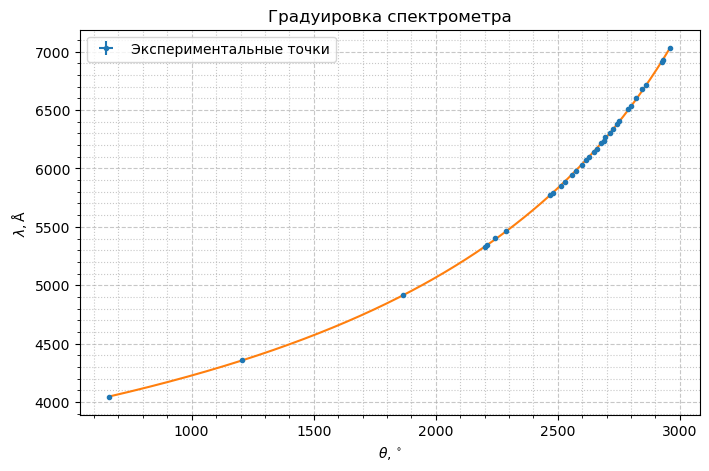

[-6.45996826e+06  2.28215741e+03  4.31986976e+03]


In [511]:
def hartmann(t, c, l0, t0):
  return l0 + c / (t - t0)


x = np.array(baraban_combined, dtype=float)
y = np.array(lambda_combined, dtype=float)

xerr = np.full_like(x, 5.0)
yerr = np.full_like(y, 5.0)

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='.', label=r'Экспериментальные точки')

popt, pcov = curve_fit(hartmann, np.array(baraban_combined), np.array(lambda_combined), p0=[4000, -700*10**4, 4000])
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = hartmann(x_fit, popt[0], popt[1], popt[2])
plt.plot(x_fit, y_fit)

plt.xlabel(rf'$\theta, ^\circ$')
plt.ylabel(rf'$\lambda, \mathrm{{\AA}}$')
plt.title(r'Градуировка спектрометра')

plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':',  alpha=0.7, which='minor')
plt.legend()
plt.show()

print(popt)
def hartmann1(t):
  return hartmann(t, popt[0], popt[1], popt[2])

для водорода

In [512]:
baraban_H_alpha = 2810
baraban_H_beta  = 1814
baraban_H_gamma = 1181

In [513]:
baraban_H = {
    "H_alpha": 2810,
    "H_beta":  1814,
    "H_gamma": 1181,
}

# Теоретические длины волн (нм) для сравнения
lines_nm_theor = {
    "H_alpha": 656.3,
    "H_beta":  486.1,
    "H_gamma": 434.0,
}

results = []

for name, n in baraban_H.items():
    lam_ang = float(hartmann1(n))        # калибровочный полином даёт λ в Å
    lam_nm = lam_ang / 10.0                  # переведём в нм
    lam_theor = lines_nm_theor.get(name)
    delta_nm = lam_nm - lam_theor if lam_theor is not None else np.nan

    results.append({
        "Линия": name,
        "Отсчёт барабана, дел.": n,
        "λ(эксп), Å": lam_ang,
        "λ(эксп), нм": lam_nm,
        "λ(теор), нм": lam_theor,
        "Δλ = λ(эксп) − λ(теор), нм": delta_nm,
    })

df_H = pd.DataFrame(results)
display(df_H)

print("\nКалиброванные длины волн линий водорода (в нм):")
for _, row in df_H.iterrows():
    print(f"{row['Линия']}: λ = {row['λ(эксп), нм']:.2f} нм, "
          f"Δλ = {row['Δλ = λ(эксп) − λ(теор), нм']:.2f} нм")

,Линия,"Отсчёт барабана, дел.","λ(эксп), Å","λ(эксп), нм","λ(теор), нм","Δλ = λ(эксп) − λ(теор), нм"
0,H_alpha,2810,6560.651113,656.065111,656.3,-0.234889
1,H_beta,1814,4860.091971,486.009197,486.1,-0.090803
2,H_gamma,1181,4340.212937,434.021294,434.0,0.021294



Калиброванные длины волн линий водорода (в нм):
H_alpha: λ = 656.07 нм, Δλ = -0.23 нм
H_beta: λ = 486.01 нм, Δλ = -0.09 нм
H_gamma: λ = 434.02 нм, Δλ = 0.02 нм


In [514]:
R = 1 / (434 * 10**-9) /(1/4 - 1/25)
R / 100

109721.3078779899

In [515]:
np.mean([109756, 109739, 109721])

np.float64(109738.66666666667)

,Линия,"Отсчёт барабана, дел.","λ(эксп), Å","λ(эксп), нм","λ(теор), нм","Δλ = λ(эксп) − λ(теор), нм",n_верхн.,"λ(аппр), нм (R_эксп)","λ(аппр), нм (R_теор)","Δλ (эксп − аппр_Rэксп), нм","Δλ (эксп − аппр_Rтеор), нм"
0,H_alpha,2810,6560.651113,656.065111,656.3,-0.234889,3,656.160330,656.335460,-0.095219,-0.270349
1,H_beta,1814,4860.091971,486.009197,486.1,-0.090803,4,486.044689,486.174415,-0.035492,-0.165218
2,H_gamma,1181,4340.212937,434.021294,434.0,0.021294,5,433.968472,434.084299,0.052821,-0.063005


Экспериментальное значение постоянной Ридберга:
R_эксп = 1.097e+07 м⁻¹
R_теор = 1.097e+07 м⁻¹
Относительное расхождение: 0.03 %

Сравнение длин волн (эксперимент vs серийная формула):
H_alpha: λ_эксп = 656.07 нм, λ_аппр(R_эксп) = 656.16 нм, Δλ = -0.10 нм
H_beta: λ_эксп = 486.01 нм, λ_аппр(R_эксп) = 486.04 нм, Δλ = -0.04 нм
H_gamma: λ_эксп = 434.02 нм, λ_аппр(R_эксп) = 433.97 нм, Δλ = 0.05 нм


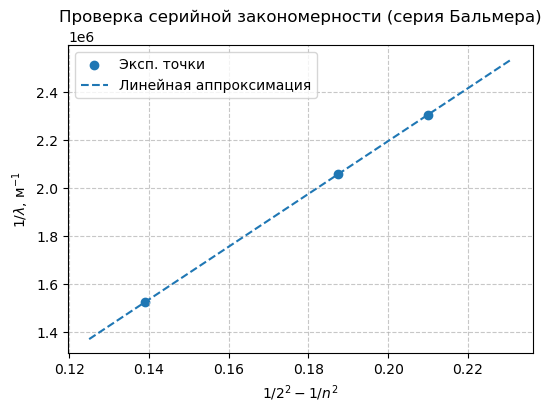

In [516]:
balmer_n = {
    "H_alpha": 3,
    "H_beta":  4,
    "H_gamma": 5,
}

mask = df_H["Линия"].isin(balmer_n.keys())
data = df_H[mask].copy()

# Перевод в метры
lam_nm = data["λ(эксп), нм"].values
lam_m = lam_nm * 1e-9

n_upper = np.array([balmer_n[name] for name in data["Линия"]])

# Серийная формула: 1/λ = R (1/2^2 - 1/n^2)
x = 1/4 - 1/(n_upper**2)
y = 1/lam_m

# Линейная аппроксимация через начало координат: y = R_exp * x
R_exp = np.sum(x * y) / np.sum(x**2)

# Теоретическое значение постоянной Ридберга (для сравнения)
R_theor = 1.097e7  # м^-1

# Предсказанные λ по экспериментальному и теоретическому R
lam_fit_exp_m = 1 / (R_exp * x)
lam_fit_theor_m = 1 / (R_theor * x)

data["n_верхн."] = n_upper
data["λ(аппр), нм (R_эксп)"] = lam_fit_exp_m * 1e9
data["λ(аппр), нм (R_теор)"] = lam_fit_theor_m * 1e9
data["Δλ (эксп − аппр_Rэксп), нм"] = data["λ(эксп), нм"] - data["λ(аппр), нм (R_эксп)"]
data["Δλ (эксп − аппр_Rтеор), нм"] = data["λ(эксп), нм"] - data["λ(аппр), нм (R_теор)"]

display(data)

print(f"Экспериментальное значение постоянной Ридберга:")
print(f"R_эксп = {R_exp:.3e} м⁻¹")
print(f"R_теор = {R_theor:.3e} м⁻¹")
print(f"Относительное расхождение: {(R_exp - R_theor)/R_theor*100:.2f} %\n")

print("Сравнение длин волн (эксперимент vs серийная формула):")
for _, row in data.iterrows():
    print(
        f"{row['Линия']}: λ_эксп = {row['λ(эксп), нм']:.2f} нм, "
        f"λ_аппр(R_эксп) = {row['λ(аппр), нм (R_эксп)']:.2f} нм, "
        f"Δλ = {row['Δλ (эксп − аппр_Rэксп), нм']:.2f} нм"
    )

# График проверки линейности 1/λ от (1/2^2 - 1/n^2)
plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Эксп. точки")
x_line = np.linspace(x.min()*0.9, x.max()*1.1, 100)
plt.plot(x_line, R_exp * x_line, label="Линейная аппроксимация", linestyle='--')
plt.xlabel(r"$1/2^2 - 1/n^2$")
plt.ylabel(r"$1 / \lambda$, м$^{-1}$")
plt.title("Проверка серийной закономерности (серия Бальмера)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

спектр йода

In [517]:
line_nu_1_0 = 2678
line_nu_1_5 = 2585
line_nu_1_edge = 2068

In [518]:
ine_nu_1_0   = 2678  # (1,0)
line_nu_1_5   = 2585  # (1,5)
line_nu_1_edge = 2068 # граница схождения (пока только посчитаем, использовать будем позже)

# Проверим, что калибровочный полином уже существует
try:
    hartmann1
except NameError:
    raise RuntimeError("Сначала запусти ячейку с построением calib_poly_Hg (градуировочный полином).")

def wavelength_A_to_energy_eV(lam_A):
    lam_nm = lam_A / 10.0
    return 1239.84 / lam_nm  # E[eV] = 1239.84 / λ[nm]

# Длины волн по градуировочному полиному (в Å)
lam_1_0_A    = float(hartmann1(line_nu_1_0))
lam_1_5_A    = float(hartmann1(line_nu_1_5))
lam_edge_A   = float(hartmann1(line_nu_1_edge))

# Перевод в нм
lam_1_0_nm  = lam_1_0_A / 10.0
lam_1_5_nm  = lam_1_5_A / 10.0
lam_edge_nm = lam_edge_A / 10.0

# Энергии фотонов в эВ
E_1_0_eV   = wavelength_A_to_energy_eV(lam_1_0_A)
E_1_5_eV   = wavelength_A_to_energy_eV(lam_1_5_A)
E_edge_eV  = wavelength_A_to_energy_eV(lam_edge_A)

# Энергия колебательного кванта возбуждённого состояния:
# h*nu_2 = (h*nu_1,5 - h*nu_1,0) / 5
# Берём модуль разности, чтобы получить положительную энергию
hnu_2_eV = abs(E_1_5_eV - E_1_0_eV) / 5.0

df_I = pd.DataFrame([
    {
        "Линия": "ν_1,0",
        "n (барабан)": line_nu_1_0,
        "λ, Å": lam_1_0_A,
        "λ, нм": lam_1_0_nm,
        "E = hν, эВ": E_1_0_eV,
    },
    {
        "Линия": "ν_1,5",
        "n (барабан)": line_nu_1_5,
        "λ, Å": lam_1_5_A,
        "λ, нм": lam_1_5_nm,
        "E = hν, эВ": E_1_5_eV,
    },
    {
        "Линия": "граница",
        "n (барабан)": line_nu_1_edge,
        "λ, Å": lam_edge_A,
        "λ, нм": lam_edge_nm,
        "E = hν, эВ": E_edge_eV,
    },
])

display(df_I)

print(f"h*ν_2 = |h*ν_1,5 - h*ν_1,0| / 5 = {hnu_2_eV:.4f} эВ")

,Линия,n (барабан),"λ, Å","λ, нм","E = hν, эВ"
0,"ν_1,0",2678,6216.676711,621.667671,1.994377
1,"ν_1,5",2585,6005.761573,600.576157,2.064418
2,граница,2068,5150.870501,515.087050,2.407049


h*ν_2 = |h*ν_1,5 - h*ν_1,0| / 5 = 0.0140 эВ


In [519]:
line_nu_1_0   = 2678   # ν_1,0
line_nu_1_5   = 2585   # ν_1,5
line_nu_1_edge = 2068  # граница полосы ν_gr

# Константы
hc_eV_nm = 1239.841984
hv1_eV   = 0.027   # колебательный квант основного состояния
EA_eV    = 0.94    # энергия возбуждения атома йода

def drum_to_lambda_A(n):
    return float(hartmann1(n))

# Длины волн (Å → nm)
lam_1_0_nm   = drum_to_lambda_A(line_nu_1_0)   / 10.0
lam_1_5_nm   = drum_to_lambda_A(line_nu_1_5)   / 10.0
lam_edge_nm  = drum_to_lambda_A(line_nu_1_edge)/ 10.0

# Энергии соответствующих квантов
E_1_0_eV  = hc_eV_nm / lam_1_0_nm
E_1_5_eV  = hc_eV_nm / lam_1_5_nm
E_edge_eV = hc_eV_nm / lam_edge_nm  # hν_гр

# Колебательный квант возбужденного состояния
hv2_eV = (E_1_5_eV - E_1_0_eV) / 5.0

# Энергия электронного перехода и энергии диссоциации
hnu_el_eV = E_1_0_eV - 0.5 * hv2_eV + 1.5 * hv1_eV
D2_eV     = E_edge_eV - hnu_el_eV + 0.5 * hv1_eV
D1_eV     = hnu_el_eV + D2_eV - EA_eV

print(f"hν_1,0  = {E_1_0_eV:.3f} эВ")
print(f"hν_1,5  = {E_1_5_eV:.3f} эВ")
print(f"hν_гр   = {E_edge_eV:.3f} эВ\n")

print(f"hν₂ (возб.) = {hv2_eV:.4f} эВ")
print(f"hν_эл       = {hnu_el_eV:.3f} эВ")
print(f"D₁ (осн.)   = {D1_eV:.3f} эВ")
print(f"D₂ (возб.)  = {D2_eV:.3f} эВ")

hν_1,0  = 1.994 эВ
hν_1,5  = 2.064 эВ
hν_гр   = 2.407 эВ

hν₂ (возб.) = 0.0140 эВ
hν_эл       = 2.028 эВ
D₁ (осн.)   = 1.481 эВ
D₂ (возб.)  = 0.393 эВ


к сдаче вопрос: почему в серии Ландера (?) верхние колебательные уровни расположены ближе чем нижние?
потому что при переходе на них атом раздувается => потенциал становится более пологим и менее глубоким - меньше энергия связи